In [1]:
from src.run_app import *
from src.prepare_gam import *
from src.utils import *
import pickle as pkl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict
from tqdm import tqdm

In [9]:
# load the dataset
dataset_name = 'bank'
path = 'datasets/{}.csv'.format(dataset_name)
dataset = pd.read_csv(path)
dataset.iloc[:, -1][dataset.iloc[:, -1] == 0] = -1
X, y = dataset.iloc[:, :-1], dataset.iloc[:, -1]

X_one_hot, count = one_hot_encoding(X, one_hot=True)
y = pd.DataFrame(y)  # {0,1}

header = list(X_one_hot.columns)
header = pd.Index(["intercept"] + header)
header = header.astype("object")

# add a column of one to X_orig and make y in {1,-1}
X_one_hot, y = utils.get_X_y(X_one_hot, y)
y = y[:, -1]

print("header dimension", len(header), flush=True)
print(X_one_hot.shape, y.shape)

header dimension 3719
(4521, 3719) (4521,)


In [11]:
from FasterRisk.src.fasterrisk import fasterrisk

### example using 3 swaps ###
# rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.008, select_top_m=100)
# rs.optimize(generate_non_integer_solution=True, test=True, swaps=3)
# beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

# # save betas and beta0 to a pickle file
# with open("compas_0.008_3.pkl", "wb") as f:
#     pkl.dump({"betas": betas, "beta0": beta0}, f)

### example with 2 swaps ###
rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.002, select_top_m=100)
rs.optimize(generate_non_integer_solution=True, test=True, swaps=2)
beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

### example with 1 swap ###
# rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.002, select_top_m=100)
# rs.optimize(generate_non_integer_solution=True, test=True, swaps=1)
# beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

0
swaps is 1: [73], [2445], [1398.26367052 1398.87572176 1399.09309744 1402.34121533 1402.34160764
 1402.40597638 1402.77007655 1402.77046843 1402.83629028 1403.03983863
 1403.04023112 1403.11921455 1403.23563674 1403.23602685 1403.29514832
 1403.29553861 1403.31989893 1403.3202916  1403.33151322 1403.37991241
 1403.38725661 1403.68093871 1403.68093871 1403.68133107 1403.68133107
 1403.74872946 1403.74872946 1403.78171636 1403.78210909 1403.84472401
 1403.84472401 1403.84472401 1403.84472401 1403.84472401 1403.84472401
 1403.84511508 1403.84511508 1403.84511508 1403.84511508 1403.84511508
 1403.84511508 1403.85306503 1403.93063296 1403.93063296 1403.93063296
 1403.93063296 1403.93063296 1403.93063296 1404.04721283 1404.04760251
 1404.05337951 1404.05377181 1404.12082023 1404.13296051 1404.21440316
 1404.21440316 1404.21440316 1404.21440316 1404.21440316 1404.21440316
 1404.21440316 1404.21440316 1404.21440316 1404.21479391 1404.21479391
 1404.21479391 1404.21479391 1404.21479391 1404.2

In [12]:
print(f"found {betas.shape[0]} models")
mean_loss = 0
for i in range(len(betas)):
    wi = betas[i, :]
    intercepti = beta0[i]
    logit = X_one_hot @ wi + intercepti
    y_pred = np.exp(logit) / (1 + np.exp(logit))
    y_pred = np.where(y_pred > 0.5, 1, -1)
    mean_loss += (y != y_pred).mean()
    print(np.nonzero(wi)[0], (y != y_pred).mean())
print(mean_loss / len(betas))

found 52 models
[  73   81 2448 2486 2487 2490 3436 3442 3679 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3436 3442 3670 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3436 3442 3478 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3278 3436 3442 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3270 3436 3442 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3235 3436 3442 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3230 3436 3442 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3214 3436 3442 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3196 3436 3679 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3196 3436 3670 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3196 3436 3478 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3196 3278 3436 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3196 3270 3436 3717] 0.10506525105065251
[  73   81 2448 2486 2487 2490 3196 3235 3436 37

100%|██████████| 52/52 [00:00<00:00, 204.04it/s]


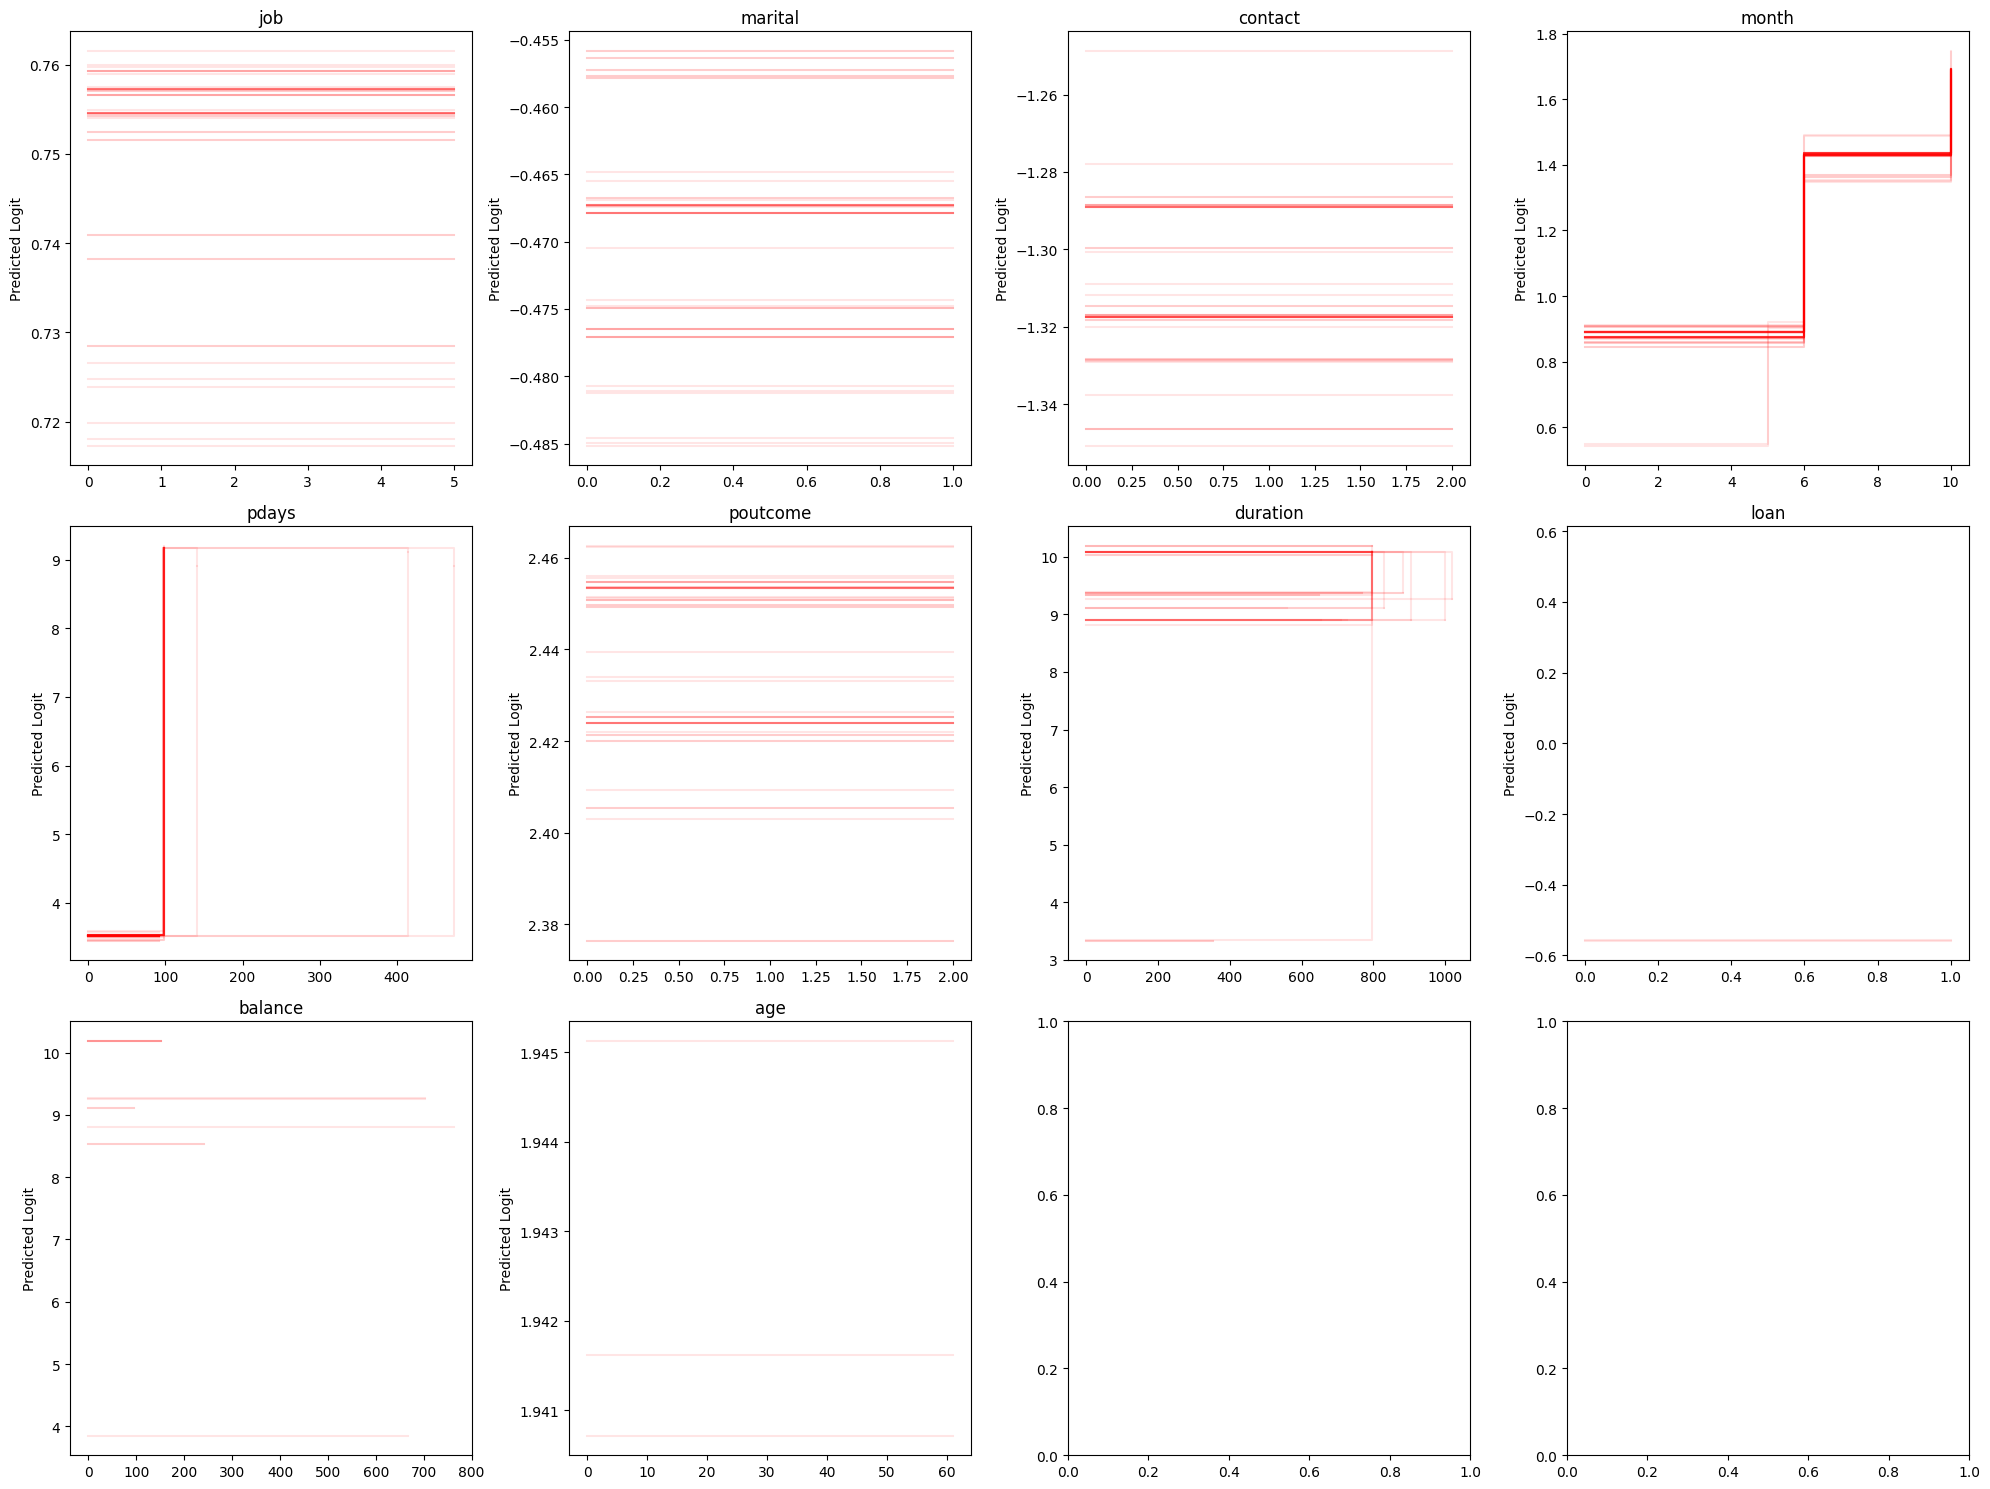

In [17]:
def get_feature_thresholds(weights, columns):
    feature_thresholds = defaultdict(list)
    for col, weight in zip(columns, weights):
        match = re.search(r'([a-zA-Z]+)', col)
        if match:
            feature = match.group(1)
            threshold = re.findall(r'[\d.]+', col)
            if feature == 'juv':
                feature = 'juv_misd_count'
            if feature == 'juvenile':
                feature = 'juvenile_crimes'
            feature_thresholds[feature].append((list(map(float, threshold)), weight))
    return feature_thresholds

def plot_gam(header, list_of_weights):
    rows = 3; cols = 4
    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(5 * cols, 5 * rows))
    axs = axs.flatten()
    ax_dict = {}
    counter = 0
    union_of_support_sets = defaultdict(int)
    for i in tqdm(range(len(list_of_weights))):
        weights = list_of_weights[i, :]
        columns = header[np.nonzero(weights)[0]]
        weights = weights[np.nonzero(weights)[0]]
        for column in columns:
            union_of_support_sets[column] += 1

        feature_thresholds = get_feature_thresholds(weights, columns)
        for feature, thresholds_weights in feature_thresholds.items():
            if feature == 'sex' or feature == 'current':
                continue
            if feature not in ax_dict:
                ax = axs[counter]
                ax_dict[feature] = ax
                counter += 1
            else:
                ax = ax_dict[feature]
            thresholds, feature_weights = zip(*thresholds_weights)

            x_vals, y_vals = [], []
            x_vals.append(0)
            y_vals.append(feature_weights[0])
            for i in range(len(thresholds) - 1):
                x_vals.append(thresholds[i][0])
                y_vals.append(feature_weights[i])

            # For the last value of the interval, add it once more
            x_vals.append(thresholds[-1][-1])
            y_vals.append(feature_weights[-1])

            ax.step(x_vals, y_vals, where="post", color='r', alpha=0.1)
            ax.set_ylabel("Predicted Logit")
            ax.set_title(feature)
    plt.tight_layout()
    plt.show()
    return union_of_support_sets

union_of_support_sets = plot_gam(header, betas[:100, :])

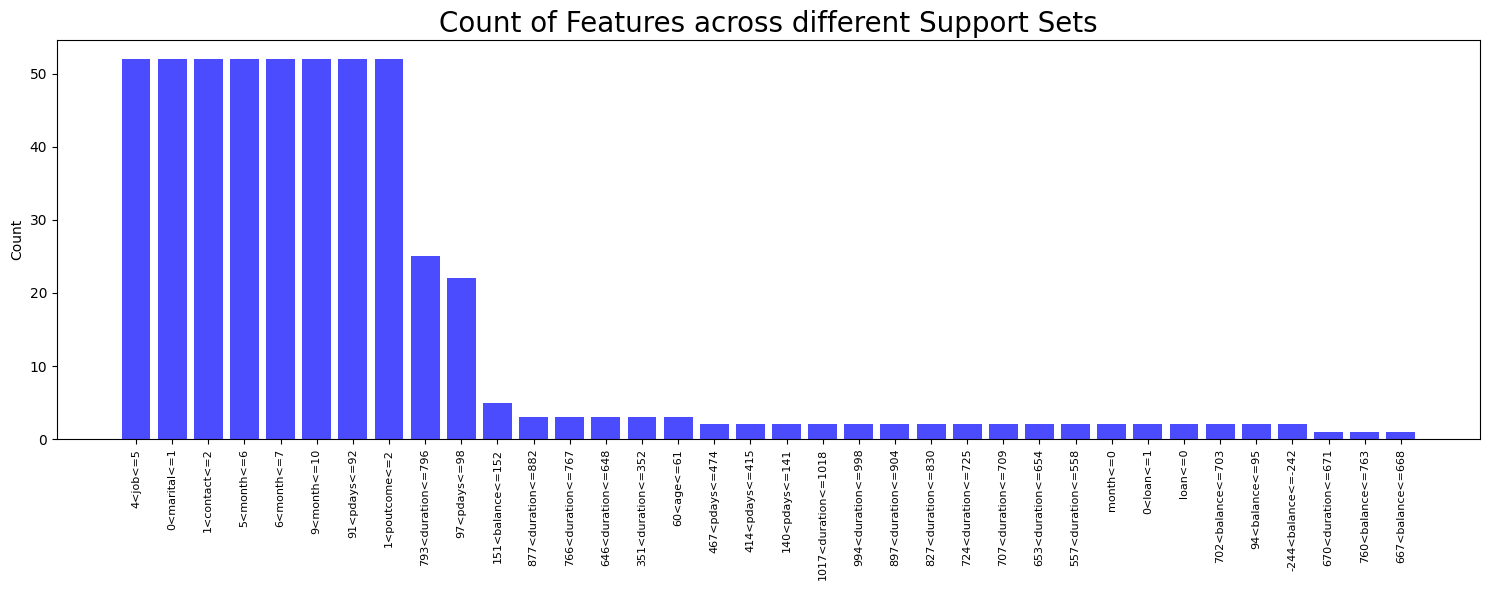

In [18]:
# Given dictionary
sorted_data = dict(sorted(union_of_support_sets.items(), key=lambda x: x[1], reverse=True))

# Prepare data for histogram
keys = list(sorted_data.keys())
values = list(sorted_data.values())

# Plot histogram
plt.figure(figsize=(15, 6))
plt.bar(keys, values, color='blue', alpha=0.7)
plt.xticks(rotation=90, fontsize=8)
plt.ylabel('Count')
plt.title('Count of Features across different Support Sets', fontsize=20)
plt.tight_layout()
plt.show()